In [3]:
import pandas as pd

df = pd.read_csv('/content/superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Retail Sales Performance Analysis

## 1. Dataset Overview


In [4]:
df.shape

(9994, 21)

In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis


## Question 1: What is the total sales and total profit of the company?


In [14]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217


### Answer

The company generated total sales of 2297200.8603000003
 and a total profit of 286397.0217.

This indicates that the business was profitable during the analyzed period.

## Question 2: Which category generates the highest sales and profit?

In [16]:
df.groupby('Category')[['Sales','Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


### Answer

Technology generated the highest sales among all categories.

This suggests that technology products are the primary revenue drivers for the business.

## Question 3:Which specific products drive the business?

In [17]:
df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


### Answer
Phones generated the highest sales among all sub categories
This suggests that Phone as a product drive the business

## Question 4: Which region performs best?

In [19]:
df.groupby('Region')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


 ### Answer
 West region performs best

## Question 5:Which states are generating the most revenue?

In [18]:
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


### Answer
The top 10 states that generate maximum revenue are :
California, New York, Texas, Washington, Pennsyivania, Florida, Illinois, Ohio, Michigan, Virginia

## Question 6: Where should the company expand?

In [20]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

,Profit
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


Company should extend in these top 10 states : California, New York, Texas, Washington, Pennsyivania, Florida, Illinois, Ohio, Michigan, Virginia.
As these are the most profitable states

## Question 7: Who are the highest-value customers?

In [21]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


### Answer
Sean Miller, Tamara Chand, Raymond Buch, Tom Ashbrook, Adrian Barton, Ken Lonsdale, Sanjit Chand,
Hunter Lopez,
Sanjit Engle, These are top 10  highest paying customers.

## Question 8: Which products should the company promote?

In [22]:
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


### Answer

The Canon imageCLASS 2200 Advanced Copier was the most profitable product, generating a profit of $25,199.93, significantly higher than all other products.

Several technology-related products such as HP printers, Canon copiers, and Zebra thermal printers also appeared among the top profit-generating products.

This indicates that office technology and printing equipment are major contributors to the company's profitability. The company should focus on promoting and maintaining inventory of these high-performing products to maximize profits.

## Visualization

#### Category-wise Sales

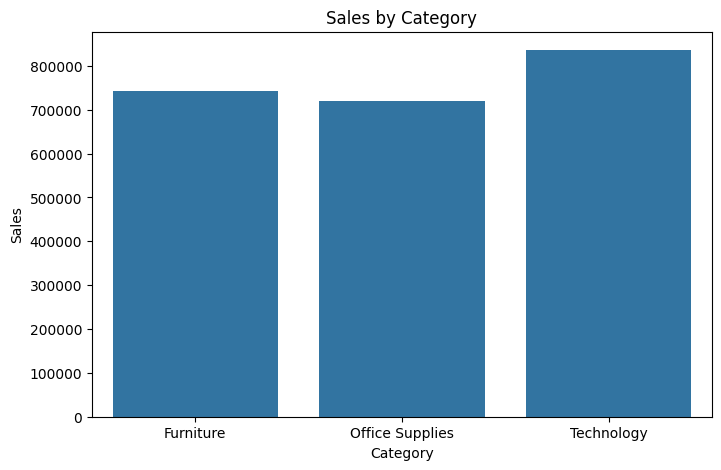

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title('Sales by Category')
plt.show()

#### Region-wise Sales

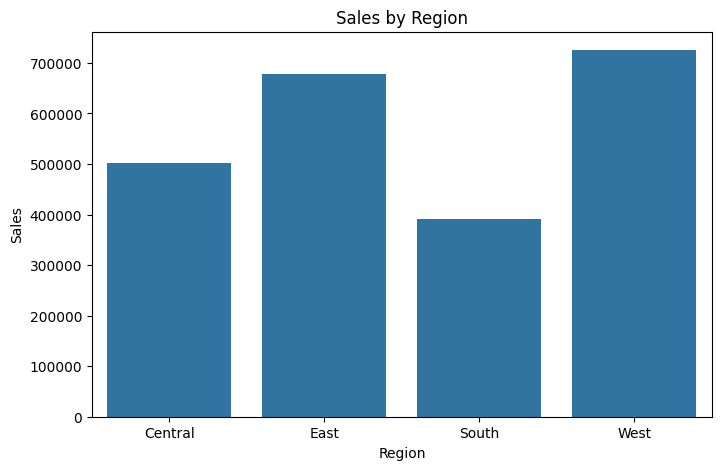

In [24]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_sales, x='Region', y='Sales')
plt.title('Sales by Region')
plt.show()

#### Top 10 States by Sales

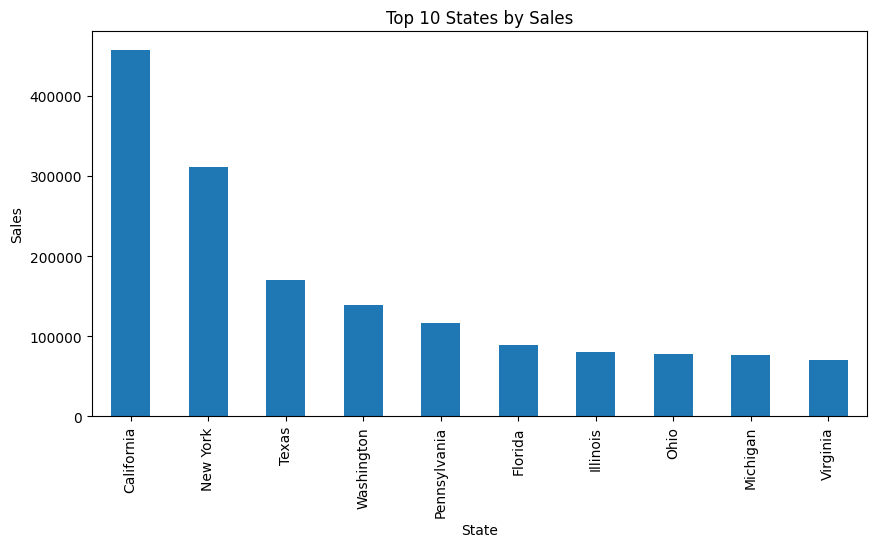

In [25]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.ylabel('Sales')
plt.show()

#### Sales vs Profit

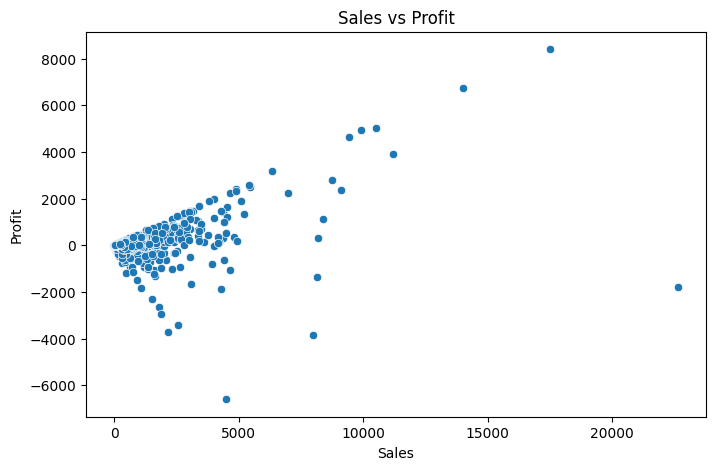

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title('Sales vs Profit')
plt.show()

#### Category Profit Distribution

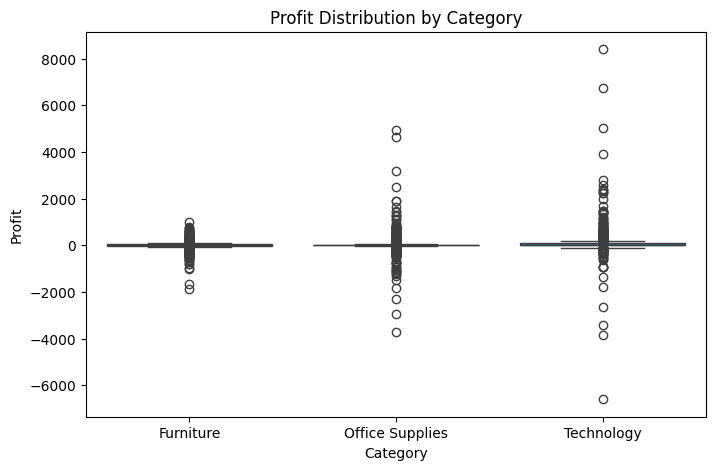

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category')
plt.show()

# Conclusion

1. Technology was the highest-performing category in terms of both sales and profit.

2. Office Supplies generated stable profits and contributed significantly to overall business performance.

3. Furniture generated considerable sales but lower profits compared to Technology.

4. Several technology and printing products were identified as highly profitable products.

5. Regional and state-level analysis helped identify high-revenue markets for potential business expansion.

Overall, the analysis provided valuable insights into sales performance, profitability, customer purchasing patterns, and product performance.